# 06: The four source types

**Development-stack notebook (LATW `dev` branch).** No Colab button: these
tutorials target the *development* versions of the LISA Analysis Tools
packages. Set up the environment by cloning LISAanalysistools and running its
installer (it lays every sibling repo out side by side and editable-installs
the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` ↔ pip releases, `dev` ↔ the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

# Stock noise curves evaluate 1/f terms at f = 0 on full grids; those bins are
# masked downstream, so silence the numpy divide warnings (as in notebook 02).
warnings.filterwarnings("ignore", category=RuntimeWarning)

# The scoring atom from notebook 02, reused for every source below.
from lisatools.analysiscontainer import AnalysisContainer
from lisatools.sensitivity import XYZ2SensitivityMatrix
from lisatools.domains import FDSignal, FDSettings, TDSignal, TDSettings


def xyz_snr(fd_full, N, dt, band, model="sangria"):
    """Score a full-length rFFT XYZ template exactly as notebook 02 did.

    ``fd_full`` is a ``(3, N//2+1)`` complex XYZ template in the LDC FD
    convention (``FD = dt * rfft(td)``). We wrap it as an ``FDSignal`` on the
    analysis ``band``, build the 3x3 XYZ noise covariance there, and hand both
    to an ``AnalysisContainer``. Returns ``(fdset, data, sens, ac, snr)``.
    """
    fdset = FDSettings(N=fd_full.shape[-1], df=1.0 / (N * dt),
                       min_freq=band[0], max_freq=band[1], force_backend="cpu")
    data = FDSignal(np.asarray(fd_full).copy(), fdset)   # auto-sliced to the band
    sens = XYZ2SensitivityMatrix(fdset, model=model)     # 3x3 Hermitian, TDI-2
    ac = AnalysisContainer(data, sens)
    return fdset, data, sens, ac, float(ac.snr())

# Slightly larger default text so labels/ticks/titles read clearly in the
# rendered figures.
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
                     "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11})


Notebooks [`04`](04_Foundations.ipynb) and [`05`](05_ResponseAndTDI.ipynb) built
the machinery — domains, sensitivity, the `AnalysisContainer`, and the LISA TDI
response. This notebook uses it on the **four astrophysical source classes** the
LISA global fit models:

- **Galactic binaries (GB)** — the millions of Milky-Way compact binaries,
- **Massive black-hole binaries (MBHB)** — the loud central-BH mergers,
- **Extreme mass-ratio inspirals (EMRI)** — small bodies spiralling into massive BHs,
- **Stellar-origin BH binaries (SOBHB)** — the LISA-band early inspiral of LIGO/Virgo-type binaries.

Each gets one `lisatools.sources` **stock class**. The point of this notebook:
these stock classes now build waveforms **byte-identically to the way the stock
`all_sources` global fit builds its defaults** — so what you learn here *is* what
the fit runs. Everything is in the **X, Y, Z** TDI channels (the workshop
default; see [`04`](04_Foundations.ipynb) §sensitivity and
[`05`](05_ResponseAndTDI.ipynb) §Why TDI), and every source is scored with the
same `AnalysisContainer` + `XYZ2SensitivityMatrix` atom via the `xyz_snr` helper
above.

**How to read this notebook.** Casual readers can follow the four `##` section
headers and their **TL;DR** cells and run the one minimal cell under each.
Pipeline developers should also read the **"Going deeper"** subsections — those
carry the parameter/transform conventions you need when you wire a source into
your own analysis. To stay laptop-cheap every example uses a **short**
observation (days, not a year) and a modest cadence.

## Galactic binaries

**TL;DR.** Galactic binaries are the millions of compact (mostly white-dwarf)
binaries in the Milky Way radiating nearly-monochromatic, slowly-chirping
continuous GWs in the mHz band; tens of thousands are individually resolvable
and the rest pile up into a confusion foreground. The stock, global-fit-aligned
waveform is **`GBXYZTDIWaveform`** (`lisatools.sources.gb`) — XYZ, TDI-2,
`EqualArmlengthOrbits`, reproducing the fit's `generate_global_template` buffer.

A Galactic binary is essentially a fixed-frequency GW source: over years its
frequency drifts only slightly (`fdot`), so in the frequency domain it is a
narrow spike a few bins wide. `GBXYZTDIWaveform` fills the **same rFFT-length FD
template** the global fit's GB injection/template path writes — the LDC-convention
`FD = dt * rfft(td)` buffer — using `GBGPU.generate_global_template` with
`tdi2=True`, `XYZ` channels and `oversample=1`.

XYZ FD template shape: (3, 262145)    Tobs = 60.681481481481484 days
GB optimal SNR (XYZ) = 59.13


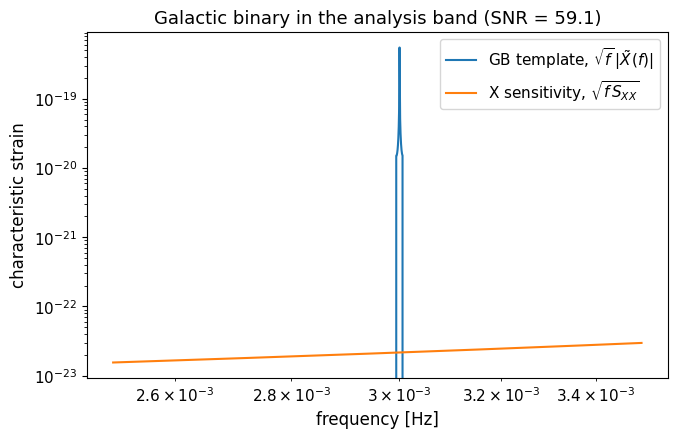

In [2]:
from lisatools.sources.gb import GBXYZTDIWaveform

dt = 10.0
Nf, Nt = 256, 2048           # a full rFFT grid: Nf*Nt time samples (~60 days)
N = Nf * Nt
Tobs = N * dt

gb = GBXYZTDIWaveform(force_backend="cpu")   # XYZ, TDI-2, EqualArmlengthOrbits

# GBGPU global-template basis: [A, f0, fdot, fddot, phi0, iota, psi, lam, beta]
params = np.array([2e-22, 3.0e-3, 1.0e-17, 0.0, 0.3, 0.7, 1.2, 2.0, 0.5])
tmpl = gb(params, Tobs, dt)                   # (3, N//2+1) XYZ FD template
print("XYZ FD template shape:", tmpl.shape, "   Tobs =", Tobs / 86400.0, "days")

fdset, data, sens, ac, snr = xyz_snr(tmpl, N, dt, band=(2.5e-3, 3.5e-3))
print(f"GB optimal SNR (XYZ) = {snr:.2f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
fb = np.asarray(fdset.f_arr)
ax.loglog(fb, np.sqrt(fb) * np.abs(np.asarray(data[0])),
          label=r"GB template, $\sqrt{f}\,|\tilde X(f)|$")
ax.loglog(fb, np.sqrt(fb * np.abs(np.asarray(sens[(0, 0)]))),
          label=r"X sensitivity, $\sqrt{f\,S_{XX}}$")
ax.set(xlabel="frequency [Hz]", ylabel="characteristic strain",
       title=f"Galactic binary in the analysis band (SNR = {snr:.1f})")
ax.legend()
plt.show()

### Going deeper: GB conventions

`GBXYZTDIWaveform(params, Tobs, dt)` takes a `(num_sources, 9)` array in the
**GBGPU global-template basis** `[A, f0, fdot, fddot, phi0, iota, psi, lam,
beta]` — linear amplitude `A`, `f0`/`fdot` in Hz / Hz s⁻¹, angles in radians,
and ecliptic sky `(lam, beta)`. It returns the LDC-convention FD buffer filled
on the full rFFT grid (the exact array the fit inverse-FFTs onto the data grid).

- **Sampling vs. waveform basis.** The sampler works in
  `A (ln), f0 (mHz), fdot, phi0, cos_iota, psi, lam, sin_beta` and fills
  `fddot = 0`; that mapping is the erebor `make_gb_transform_container`
  (`lisatools.globalfit.stock.erebor.transforms`).
- `GBAETWaveform` (same module) is a legacy per-source `(A, E, T)` wrapper kept
  for back-compat — prefer the XYZ class above.
- The waveform engine and its own tutorials live in **GBGPU**
  ([docs](https://lisa-analysis-tools.github.io/GBGPU)); the fast per-source GB response
  is the TDI-on-the-fly path from [`05`](05_ResponseAndTDI.ipynb), used at scale
  in [`02`](02_StockGlobalFitsInDepth.ipynb).

## Massive black-hole binaries

**TL;DR.** MBHBs are mergers of ~10⁴–10⁷ M⊙ black holes at the centres of
merging galaxies — the **loudest** LISA sources, sweeping through the band to
merger with SNRs in the hundreds–thousands. The stock, global-fit-aligned
waveform is **`PhenomTHMTDIWaveform`** (`lisatools.sources.bbh`): a phentax
`IMRPhenomTHM` intrinsic waveform put through the LISA pyResponseTDI response
(2nd-gen TDI, XYZ). Keep the generation window **short** — a full-span phentax
generation OOMs a laptop.

Unlike a Galactic binary, an MBHB is a genuine chirp: over the last days–weeks
before merger its frequency sweeps up through the LISA band, ending in a
high-amplitude merger and ringdown. Below we generate only the last **7 days**
before merger (a laptop-safe window) and look at the raw XYZ TDI time series —
the inspiral-merger-ringdown morphology is unmistakable.

No CuPy


_apply_response: zeroed 48 non-finite TDI sample(s) INSIDE the data span (TDI warm-up at the orbit-span edge; expected ~O(10) at a t=0 orbit start — investigate if large).


XYZ TDI shape: (3, 54926)
MBHB optimal SNR (XYZ) = 3569   (the loudest LISA sources)


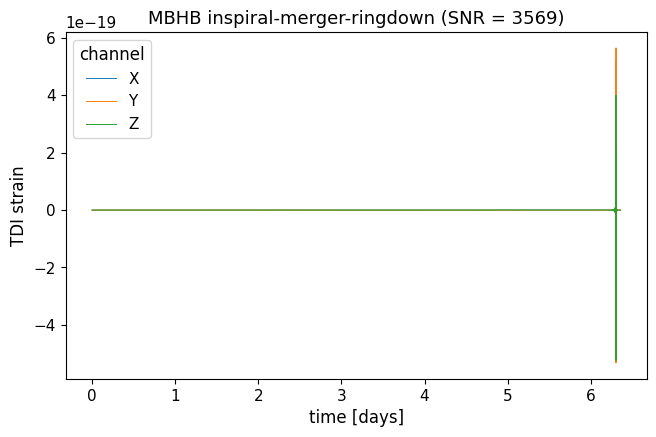

In [3]:
from lisatools.sources.bbh import PhenomTHMTDIWaveform
from lisatools.detector import EqualArmlengthOrbits

dt = 10.0
Tobs_wf = 7.0 * 86400.0            # SHORT phentax generation window (7 days)
Ndata = int(round(Tobs_wf / dt)) + 4096

# Aligned defaults are baked in: IMRPhenomTHM higher modes (21, 33, 44) +
# negative modes, 2nd-gen TDI, XYZ, response order 30. Only the run-specific
# grid / orbits / t0 are passed here.
mbh = PhenomTHMTDIWaveform(
    waveform_t0=0.0,
    data_td_settings=TDSettings(N=Ndata, dt=dt, t0=0.0, force_backend="cpu"),
    Tobs=Tobs_wf,
    sampling_frequency=1.0 / dt,
    orbits=EqualArmlengthOrbits(force_backend="cpu"),
    force_backend="cpu",
)

# compute_tdi_channels(m1, m2, s1z, s2z, dist[Mpc], phi_ref, iota, psi,
#                      ra, dec, merger_time)  ->  (times, XYZ channels)
merger_time = 0.9 * Tobs_wf         # place the merger near the end of the window
times, chans = mbh.compute_tdi_channels(
    1.2e6, 0.8e6, 0.3, 0.2, 15000.0, 1.0, 1.0, 1.2, 2.0, 0.4, merger_time)
chans = np.asarray(chans)
if chans.ndim == 3:                 # single-source path returns (1, 3, Ntimes)
    chans = chans[0]
times = np.asarray(times)
if times.ndim == 2:
    times = times[0]
N = chans.shape[-1]
print("XYZ TDI shape:", chans.shape)

fd = TDSignal(chans, TDSettings(N=N, dt=dt, force_backend="cpu")).fft()
fdset, data, sens, ac, snr = xyz_snr(np.asarray(fd.arr), N, dt, band=(1e-4, 2.5e-2))
print(f"MBHB optimal SNR (XYZ) = {snr:.0f}   (the loudest LISA sources)")

tt = (times - times[0]) / 86400.0
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for lab, i, c in zip("XYZ", range(3), ("C0", "C1", "C2")):
    ax.plot(tt, np.asarray(chans[i]), color=c, lw=0.7, label=lab)
ax.set(xlabel="time [days]", ylabel="TDI strain",
       title=f"MBHB inspiral-merger-ringdown (SNR = {snr:.0f})")
ax.legend(title="channel")
plt.show()

### Going deeper: MBHB conventions

`compute_tdi_channels(m1, m2, s1z, s2z, dist[Mpc], phi_ref, iota, psi, ra, dec,
merger_time)` returns raw `(times, XYZ channels)` in the time domain
(`merger_time` is measured from `waveform_t0`); the object is also directly
callable — `mbh(...)` returns the domain-projected signal the fit scores.

- **Aligned defaults** come from the module-level `MBH_PHENOM_DEFAULT_*`
  constants (higher modes `(21, 33, 44)`, negative modes on, 2nd-gen TDI, XYZ,
  response order 30, 15000 s buffer). `Tobs` is the *phentax generation window*,
  not the data span — keep it short (`coarse_grain=False` is required, and a
  full-year window OOMs a laptop).
- **Sampling basis.** The sampler works in
  `logM, Q (= m1/m2), s1z, s2z, dist (Gpc), phi_ref, cos_iota, psi, alpha (RA),
  sin_delta, t_plunge` in the **ICRS** run frame; the mapping is the erebor
  `make_mbh_transform_container` (direct `alpha`/`delta`, no frame conversion —
  the orbits are loaded with `frame="icrs"`).
- For a quick SNR forecast without the full response, `BBHSNRWaveform`
  (`lisatools.sources.bbh`, built on bbhx `BBHWaveformFD`) evaluates a sparse
  log-spaced FD waveform and reports the **A, E, T** SNR — handy, but it is *not*
  the global-fit residual template and it is the one place we quote AET, not XYZ.
- The intrinsic waveform is phentax `IMRPhenomTHM`; the FD/TDI-on-the-fly engines
  live in **BBHx** ([docs](https://lisa-analysis-tools.github.io/BBHx)).

## Extreme mass-ratio inspirals

**TL;DR.** An EMRI is a stellar-mass compact object (~10 M⊙) spiralling into a
massive black hole (~10⁶ M⊙) over ~10⁵ orbits, producing an intricate
multi-harmonic waveform that finely maps the Kerr geometry. The stock,
global-fit-aligned waveform is **`EMRITDIWaveform`** (`lisatools.sources.emri`),
which delegates to the fit's `get_emri_response_wrapper`: FEW
`FastKerrEccentricEquatorialFlux`, 2nd-gen TDI, XYZ, response `order=40`,
`remove_garbage="zero"`.

The richness is the point: many orbital harmonics (radial, azimuthal and their
combinations) beat together, so even a short slice of the TD signal looks busy
and the FD spectrum is a comb of lines. Building the FEW generator is the slow
step (~1 min on CPU); we keep the observation short (`T = 0.1 yr`) so the
generation itself stays cheap.

XYZ TDI shape: (3, 315581)    Tobs = 36.5255787037037 days


EMRI optimal SNR (XYZ) = 8.47


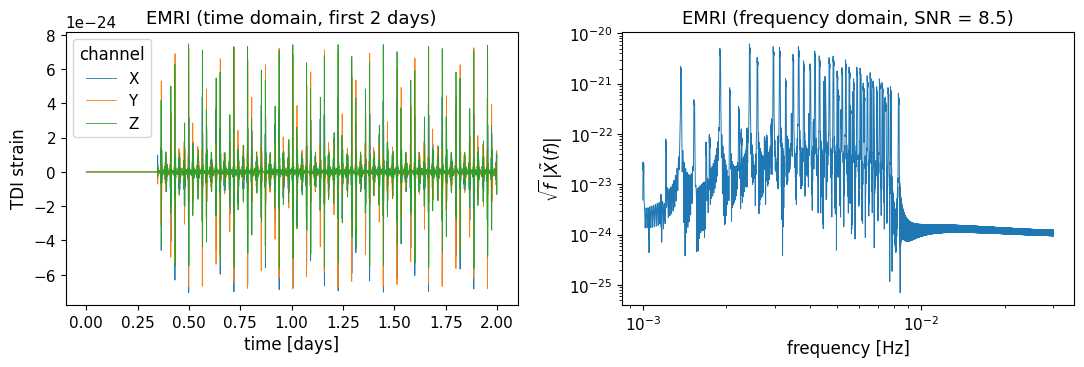

In [4]:
from lisatools.sources.emri import EMRITDIWaveform

dt = 10.0
emri = EMRITDIWaveform(T=0.1, dt=dt, t0=0.0, force_backend="cpu")   # 0.1 yr; XYZ, TDI-2, order 40

# FEW 14-parameter basis: [M, mu, a, p0, e0, xI0, dist(Gpc),
#                          qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
p = [1e6, 10.0, 0.5, 12.0, 0.3, 1.0, 1.0, 0.8, 2.0, 1.5, 1.2, 1.0, 2.0, 3.0]
chans = np.asarray([np.asarray(c) for c in emri(*p)])    # (3, N) XYZ TDI
N = chans.shape[-1]
print("XYZ TDI shape:", chans.shape, "   Tobs =", N * dt / 86400.0, "days")

fd = TDSignal(chans, TDSettings(N=N, dt=dt, force_backend="cpu")).fft()
fdset, data, sens, ac, snr = xyz_snr(np.asarray(fd.arr), N, dt, band=(1e-3, 3e-2))
print(f"EMRI optimal SNR (XYZ) = {snr:.2f}")

tt = np.arange(N) * dt / 86400.0
zoom = tt < 2.0
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
for lab, i, c in zip("XYZ", range(3), ("C0", "C1", "C2")):
    a0.plot(tt[zoom], np.asarray(chans[i])[zoom], color=c, lw=0.6, label=lab)
a0.set(xlabel="time [days]", ylabel="TDI strain",
       title="EMRI (time domain, first 2 days)")
a0.legend(title="channel")
fb = np.asarray(fdset.f_arr)
a1.loglog(fb, np.sqrt(fb) * np.abs(np.asarray(data[0])), color="C0", lw=0.7)
a1.set(xlabel="frequency [Hz]", ylabel=r"$\sqrt{f}\,|\tilde X(f)|$",
       title=f"EMRI (frequency domain, SNR = {snr:.1f})")
fig.tight_layout()
plt.show()

### Going deeper: EMRI conventions

`EMRITDIWaveform(*p)` takes the **FEW 14-parameter basis**
`[M, mu, a, p0, e0, xI0, dist(Gpc), qS, phiS, qK, phiK, Phi_phi0, Phi_theta0,
Phi_r0]`: the sky is the **ecliptic-polar** pair `(qS, phiS)` and the spin is
`(qK, phiK)`; `FastKerrEccentricEquatorialFlux` is an equatorial model, so
`xI0 = +1`.

- By default `special_frame=True`: every call converts the ecliptic-polar sky to
  the ICRS orbit frame (the validated mojito / `all_sources` path). Pass
  `special_frame=False` for a plain ecliptic-frame smoke waveform.
- **Sampling basis.** The sampler works in a 12-parameter basis
  (`logm1, m2, a, p0, e0, dist, cos qS, phiS, cos qK, phiK, Phi_phi0, Phi_r0`)
  with `xI0` and `Phi_theta0` filled; the mapping is the erebor
  `make_emri_transform_container(fill_values)`.
- The intrinsic waveform engine is **FastEMRIWaveforms (FEW)**
  ([docs](https://bhptoolkit.org/FastEMRIWaveforms)); the LISA response is the
  `ResponseWrapper` from [`05`](05_ResponseAndTDI.ipynb).

## Stellar-origin black-hole binaries

**TL;DR.** SOBHBs are the LISA-band *early inspiral* of the same ~10–100 M⊙
black-hole binaries LIGO/Virgo later hear merge — years-long, nearly
monochromatic, and individually quiet (SNR of a few). THE documented stock entry
is **`build_sobbh_stock_waveform`** (`lisatools.sources.sobbh.response`): a PN
inspiral projected with the **TDI-on-the-fly** response — the `all_sources`
SOBBH default (`use_tdionfly=True`).

This stock builder is different from the other three in a useful way: it returns
a **domain-projected `DomainBase` signal directly** (here an `FDSignal` on the
analysis band), because the on-the-fly response evaluates and projects in one
step. You give it the run essentials — `Tobs`, `dt`, the data `TDSettings`, the
`target_domain`, and a `TDIConfig` — and call it on the source parameters.

domain-projected signal: FDSignal (3, 193987)
SOBHB optimal SNR (XYZ) = 6.09   (LISA-band inspiral; individually quiet)


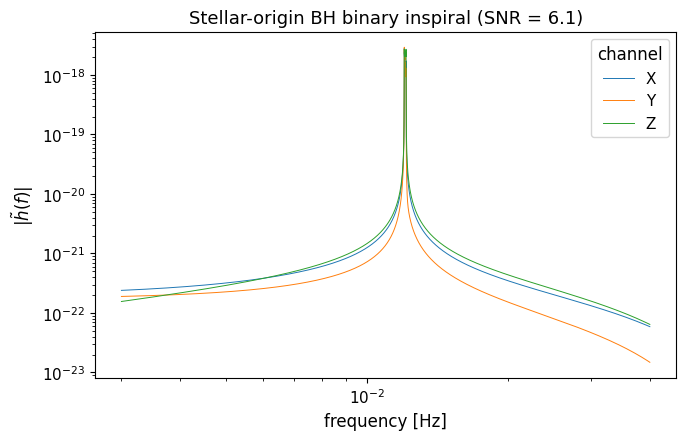

In [5]:
from lisatools.sources.sobbh.response import build_sobbh_stock_waveform
from lisatools.response.tdiconfig import TDIConfig

dt = 10.0
N = 1 << 19                    # 524288 TD samples (~60 days)
Tobs = N * dt
data_length = N // 2 + 1
band = (3e-3, 4e-2)

td_settings = TDSettings(N=N, dt=dt, t0=0.0, force_backend="cpu")
fd_target = FDSettings(N=data_length, df=1.0 / (N * dt),
                       min_freq=band[0], max_freq=band[1], force_backend="cpu")
tdi_config = TDIConfig("2nd generation", force_backend="cpu")

# THE stock all_sources SOBBH builder (TDI-on-the-fly); returns a domain object.
wave = build_sobbh_stock_waveform(
    Tobs=Tobs, dt=dt, t_start=0.0,
    td_settings=td_settings, target_domain=fd_target,
    tdi_config=tdi_config, force_backend="cpu", nchannels=3)

# SOBBH waveform basis: (m1, m2, s1, s2, dist[Gpc], inc, f_low, ra, dec, psi, phi0)
params = (45.0, 38.0, 0.0, 0.0, 0.1, 0.9, 1.2e-2, 2.0, 0.4, 1.0, 1.0)
sig = wave(*params)            # <-- an FDSignal already on the analysis band
sens = XYZ2SensitivityMatrix(fd_target, model="sangria")
ac = AnalysisContainer(sig, sens)
snr = float(ac.snr())
print("domain-projected signal:", type(sig).__name__, np.asarray(sig.arr).shape)
print(f"SOBHB optimal SNR (XYZ) = {snr:.2f}   (LISA-band inspiral; individually quiet)")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
fb = np.asarray(fd_target.f_arr)
for lab, i, c in zip("XYZ", range(3), ("C0", "C1", "C2")):
    ax.loglog(fb, np.abs(np.asarray(sig.arr[i])), color=c, lw=0.7, label=lab)
ax.set(xlabel="frequency [Hz]", ylabel=r"$|\tilde h(f)|$",
       title=f"Stellar-origin BH binary inspiral (SNR = {snr:.1f})")
ax.legend(title="channel")
plt.show()

### Going deeper: SOBHB conventions

`build_sobbh_stock_waveform(...)` returns a callable on the **11-parameter SOBBH
waveform basis** `(m1, m2, s1, s2, dist[Gpc], inc, f_low, ra, dec, psi, phi0)`,
where `f_low` is the starting GW frequency and `phi0` is the catalogue
`TrueAnomaly` (the orbital phase at `f_low`, *not* the coalescence phase). It
returns a `DomainBase` signal projected onto `target_domain`.

- Under the hood it reuses the PN `SOBBHWaveform` amplitude/phase and projects
  through bbhx `SOBBHTDIonFly` (validated on-the-fly response). The legacy
  pyResponse path (`get_sobbh_response_wrapper`) is the `use_tdionfly=False`
  fallback only.
- `reference_time` is the epoch `f_low` is defined at (`MOJITO_REFERENCE_TIME` in
  mojito mode; defaults to the window start).
- **Sampling basis.** The sampler works in
  `logm1, logm2, s1, s2, dist, cos inc, f_low, phiS, cos qS, psi, phi0`; the
  mapping is the erebor `make_sobbh_transform_container`.
- The TDI-on-the-fly engine lives in **BBHx**
  ([docs](https://lisa-analysis-tools.github.io/BBHx)); see the on-the-fly family in
  [`05`](05_ResponseAndTDI.ipynb).

## Where to go next

You have now built one of each LISA source class with the exact stock waveforms
the global fit runs, scored each with the same `AnalysisContainer` +
`XYZ2SensitivityMatrix` atom, and seen the four morphologies — a narrow GB spike,
a loud MBHB chirp-merger, a busy multi-harmonic EMRI, and a quiet SOBHB inspiral.

- [`07`](07_ErynSmallToLarge.ipynb) — sampling these sources with Eryn.
- [`02`](02_StockGlobalFitsInDepth.ipynb) — the
  stock global fits that batch thousands of these residuals at once (the
  *small → large* payoff from [`04`](04_Foundations.ipynb)).